# Aditya Rana
# I059
# B'Tech AI B2 Batch

# ATML Lab 4 - Generative Adversarial Networks (GAN)

Implementation of a simple GAN on the Fashion MNIST dataset.

## Task 1: Paper Review - Generative Adversarial Nets (Goodfellow et al., 2014)

Paper link: https://arxiv.org/abs/1406.2661

### 1. Paper Overview
This paper introduces a framework for training generative models through a competitive process. It involves two neural networks:
- **The Generator (G):** Creates fake data samples that look like real training data.
- **The Discriminator (D):** Acts as a judge, trying to distinguish between real data and the "fake" samples produced by $G$.

The two models compete: $D$ learns to become a better detective, while $G$ learns to become a better counterfeiter. This is trained using standard **backpropagation**, avoiding the need for complex Markov chains.

---

### 2. Minimax Formulation
The training is defined as a mathematical **minimax game** using the following value function $V(D, G)$:

$$\min_{G} \max_{D} V(D, G) = \mathbb{E}_{x\sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z\sim p_{z}(z)}[\log(1 - D(G(z)))]$$

**How it works:**
- **Discriminator (Maximize):** $D$ wants to maximize the probability of correctly labeling real data as "1" ($D(x)$) and fake data as "0" ($D(G(z))$).
- **Generator (Minimize):** $G$ wants the discriminator to fail. It tries to minimize $\log(1 - D(G(z)))$, which means making $D(G(z))$ as close to 1 as possible.
- **Result:** Ideally, $G$ eventually produces data so realistic that the discriminator can only guess randomly (probability of 0.5).

---

### 3. Advantages and Challenges

**Advantages:**
- **Efficiency:** No need for Markov chains or unrolled approximate inference during training or sampling.
- **Flexibility:** Any differentiable function (like deep neural networks) can be used for $G$ and $D$.
- **Sharper Results:** GANs produce very sharp and realistic images compared to other generative models that often result in "blurry" outputs.

**Challenges:**
- **Mode Collapse:** The generator might find a specific "type" of data that fools the discriminator and keep producing only that, leading to a lack of variety.
- **Instability:** Training requires careful synchronization between $D$ and $G$. If one learns too much faster than the other, the model fails to improve.
- **Evaluation:** There is no easy way to mathematically calculate how "good" the model is; evaluation often relies on visual inspection.

## Task 2: Load and Prepare Fashion MNIST

In [3]:
!pip install matplotlib

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

In [5]:
# Load dataset
(x_train, _), (_, _) = fashion_mnist.load_data()
print("Original shape:", x_train.shape)

# Normalize to range (-1, 1)
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Reshape: add channel dimension so one sample can be fed to the network
x_train = x_train.reshape(-1, 28, 28, 1)
print("Reshaped:", x_train.shape)
print("Min:", x_train.min(), "Max:", x_train.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original shape: (60000, 28, 28)
Reshaped: (60000, 28, 28, 1)
Min: -1.0 Max: 1.0


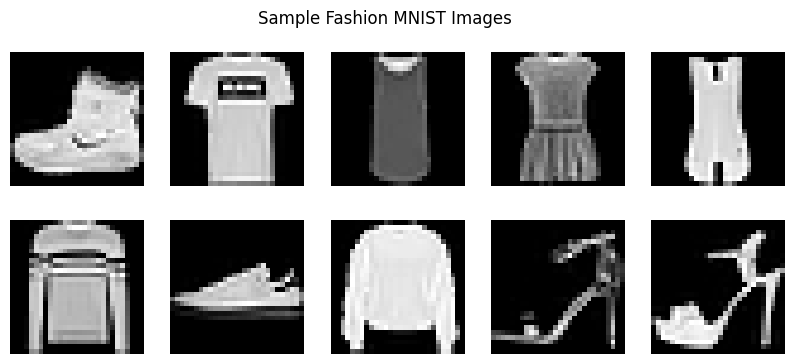

In [6]:
# Plot some sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
plt.suptitle("Sample Fashion MNIST Images")
plt.show()

In [7]:
# Batch the data using tf.data
BATCH_SIZE = 32
BUFFER_SIZE = x_train.shape[0]

dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)
print("Number of batches:", len(dataset))

Number of batches: 1875


## Task 3: Build the Generator Network

In [8]:
NOISE_DIM = 100

def build_generator(noise_dim=NOISE_DIM):
    model = models.Sequential([
        layers.Dense(256, input_shape=(noise_dim,)),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(momentum=0.8),

        layers.Dense(512),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(momentum=0.8),

        layers.Dense(1024),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(momentum=0.8),

        layers.Dense(28 * 28 * 1, activation="tanh"),
        layers.Reshape((28, 28, 1)),
    ], name="Generator")
    return model

generator = build_generator()
generator.summary()

c:\Users\Aditya Rana\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Aditya Rana\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

## Task 4: Build the Discriminator Network

In [9]:
def build_discriminator():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(512),
        layers.LeakyReLU(alpha=0.2),

        layers.Dense(256),
        layers.LeakyReLU(alpha=0.2),

        layers.Dense(1, activation="sigmoid"),
    ], name="Discriminator")
    return model

discriminator = build_discriminator()
discriminator.summary()

c:\Users\Aditya Rana\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Task 5: Build the GAN Network

In [10]:
# Compile the discriminator first
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Freeze the discriminator when training the combined GAN
discriminator.trainable = False

gan = models.Sequential([generator, discriminator], name="GAN")
gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss="binary_crossentropy",
)
gan.summary()

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Generator (Sequential)          │ (None, 28, 28, 1)      │     1,493,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,025 (7.73 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 537,089 (2.05 MB)

## Task 6: Choose appropriate optimizer and compile the model.

In [11]:
def plot_generated_images(generator, n=10, noise_dim=NOISE_DIM, title=""):
    noise = np.random.normal(0, 1, (n, noise_dim))
    gen_imgs = generator.predict(noise, verbose=0)
    # Rescale from [-1, 1] to [0, 1]
    gen_imgs = 0.5 * gen_imgs + 0.5

    fig, axes = plt.subplots(1, n, figsize=(n * 1.2, 1.5))
    for i, ax in enumerate(axes):
        ax.imshow(gen_imgs[i].reshape(28, 28), cmap="gray")
        ax.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

In [12]:
def train_gan(epochs, batch_size=BATCH_SIZE, noise_dim=NOISE_DIM, plot_every=None):
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_losses, g_losses = [], []

    for epoch in range(1, epochs + 1):
        # Sample a random batch of real images
        idx = np.random.randint(0, x_train.shape[0], batch_size)
        real_imgs = x_train[idx]

        # Generate fake images
        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        fake_imgs = generator.predict(noise, verbose=0)

        # Train the discriminator
        discriminator.trainable = True
        d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)
        d_loss = 0.5 * (np.array(d_loss_real) + np.array(d_loss_fake))

        # Train the generator (via the GAN model)
        discriminator.trainable = False
        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        g_loss = gan.train_on_batch(noise, real_labels)

        d_losses.append(d_loss[0])
        g_losses.append(g_loss)

        if epoch % max(1, epochs // 10) == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} | D loss: {d_loss[0]:.4f} | D acc: {d_loss[1]*100:.1f}% | G loss: {g_loss:.4f}")
            if plot_every and epoch % plot_every == 0:
                plot_generated_images(generator, title=f"Epoch {epoch}")

    return d_losses, g_losses

Epoch 1/2000 | D loss: 0.9074 | D acc: 25.8% | G loss: 0.7299
Epoch 200/2000 | D loss: 0.0586 | D acc: 98.5% | G loss: 3.8597
Epoch 400/2000 | D loss: 0.1960 | D acc: 92.5% | G loss: 3.4595
Epoch 600/2000 | D loss: 0.3342 | D acc: 84.7% | G loss: 2.7105
Epoch 800/2000 | D loss: 0.4010 | D acc: 80.4% | G loss: 2.2879
Epoch 1000/2000 | D loss: 0.4396 | D acc: 77.9% | G loss: 2.0273


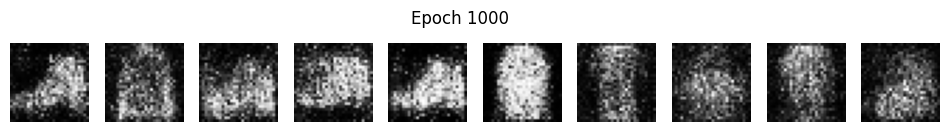

Epoch 1200/2000 | D loss: 0.4667 | D acc: 76.2% | G loss: 1.8482
Epoch 1400/2000 | D loss: 0.4886 | D acc: 74.7% | G loss: 1.7152
Epoch 1600/2000 | D loss: 0.5046 | D acc: 73.6% | G loss: 1.6142
Epoch 1800/2000 | D loss: 0.5169 | D acc: 72.8% | G loss: 1.5354
Epoch 2000/2000 | D loss: 0.5263 | D acc: 72.1% | G loss: 1.4750


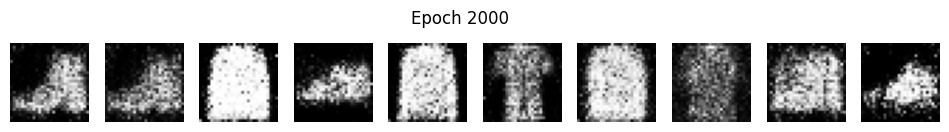

In [13]:
EPOCHS = 2000
d_losses, g_losses = train_gan(epochs=EPOCHS, plot_every=500)

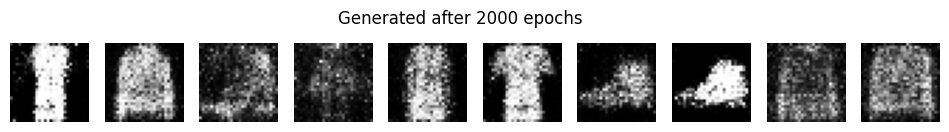

In [14]:
# Final generated images
plot_generated_images(generator, n=10, title=f"Generated after {EPOCHS} epochs")

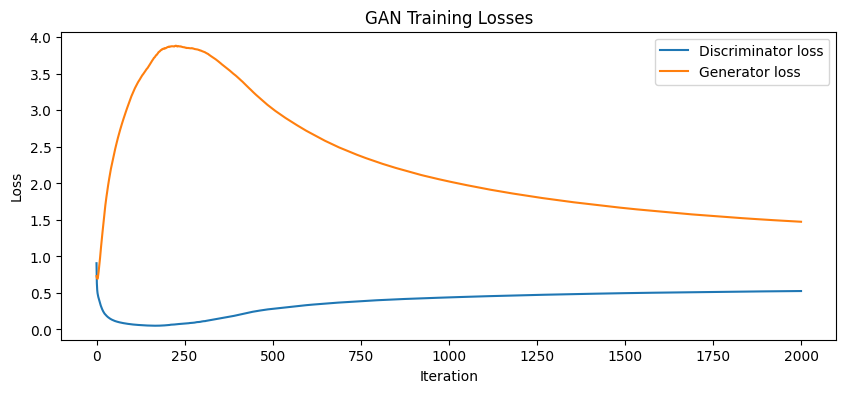

In [15]:
# Plot training losses
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label="Discriminator loss")
plt.plot(g_losses, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN Training Losses")
plt.show()

Epoch 1/3000 | D loss: 0.5263 | D acc: 72.1% | G loss: 1.4747
Epoch 300/3000 | D loss: 0.5370 | D acc: 71.4% | G loss: 1.4069
Epoch 600/3000 | D loss: 0.5460 | D acc: 70.8% | G loss: 1.3562
Epoch 900/3000 | D loss: 0.5533 | D acc: 70.2% | G loss: 1.3147
Epoch 1200/3000 | D loss: 0.5600 | D acc: 69.7% | G loss: 1.2799
Epoch 1500/3000 | D loss: 0.5659 | D acc: 69.2% | G loss: 1.2513
Epoch 1800/3000 | D loss: 0.5710 | D acc: 68.8% | G loss: 1.2277
Epoch 2100/3000 | D loss: 0.5755 | D acc: 68.4% | G loss: 1.2070
Epoch 2400/3000 | D loss: 0.5797 | D acc: 68.0% | G loss: 1.1884
Epoch 2700/3000 | D loss: 0.5837 | D acc: 67.7% | G loss: 1.1719
Epoch 3000/3000 | D loss: 0.5873 | D acc: 67.4% | G loss: 1.1569


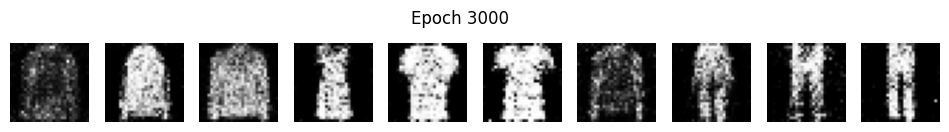

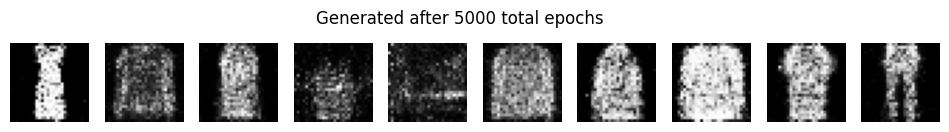

In [16]:
# Train for more epochs to observe improvement in quality
MORE_EPOCHS = 3000
d_losses2, g_losses2 = train_gan(epochs=MORE_EPOCHS, plot_every=1000)
plot_generated_images(generator, n=10, title=f"Generated after {EPOCHS + MORE_EPOCHS} total epochs")

## Conclusion

- Implemented a basic GAN with a fully-connected generator and discriminator on Fashion MNIST.
- The generator learns to map a noise vector $z \sim \mathcal{N}(0,1)$ to a $(28 \times 28 \times 1)$ image, while the discriminator learns to distinguish real from fake samples.
- As the number of training epochs increases, the generated images become progressively closer to real Fashion MNIST items, though the simple MLP architecture limits sharpness (a DCGAN with convolutional layers would give better results).
- Training is unstable: the generator and discriminator losses oscillate as expected in the adversarial minimax game.